# **Building Energy Load Prediction Using ML and DL**
**Group 1**

This project aims to predict building energy consumption using machine learning.

**Key steps:**
- Exploratory Data Analysis (EDA) and data cleaning
- Feature engineering and preprocessing
- Training multiple models (Linear Regression, Random Forest, XGBoost, ANN, LSTM)
- Model evaluation using RMSE, MAE, MAPE, and R²

The goal is to identify key factors affecting energy usage and build accurate predictive models.


<a href="https://colab.research.google.com/github/Wadha-Abdulla/Group_1_AirQuality_Analysis/blob/main/Group_1_AirQuality_Analysis.ipynb" target="_parent">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

# 1. Data Exploration

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Data Science/energydata_complete.csv')

df.head()

,date,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,...,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2
0,2016-01-11 17:00:00,60,30,19.89,47.596667,19.2,44.790000,19.79,44.730000,19.000000,...,17.033333,45.53,6.600000,733.5,92.0,7.000000,63.000000,5.3,13.275433,13.275433
1,2016-01-11 17:10:00,60,30,19.89,46.693333,19.2,44.722500,19.79,44.790000,19.000000,...,17.066667,45.56,6.483333,733.6,92.0,6.666667,59.166667,5.2,18.606195,18.606195
2,2016-01-11 17:20:00,50,30,19.89,46.300000,19.2,44.626667,19.79,44.933333,18.926667,...,17.000000,45.50,6.366667,733.7,92.0,6.333333,55.333333,5.1,28.642668,28.642668
3,2016-01-11 17:30:00,50,40,19.89,46.066667,19.2,44.590000,19.79,45.000000,18.890000,...,17.000000,45.40,6.250000,733.8,92.0,6.000000,51.500000,5.0,45.410389,45.410389
4,2016-01-11 17:40:00,60,40,19.89,46.333333,19.2,44.530000,19.79,45.000000,18.890000,...,17.000000,45.40,6.133333,733.9,92.0,5.666667,47.666667,4.9,10.084097,10.084097


**Dataset Understanding & Cleaning**

In [ ]:
# Display the first 5 rows of the dataset
df.head()

# Shows number of rows, columns, data types, and non-null values
df.info()

# Display statistical summary of numerical features
# mean, standard deviation, min, max, and quartiles
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19735 entries, 0 to 19734
Data columns (total 29 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   date         19735 non-null  object 
 1   Appliances   19735 non-null  int64  
 2   lights       19735 non-null  int64  
 3   T1           19735 non-null  float64
 4   RH_1         19735 non-null  float64
 5   T2           19735 non-null  float64
 6   RH_2         19735 non-null  float64
 7   T3           19735 non-null  float64
 8   RH_3         19735 non-null  float64
 9   T4           19735 non-null  float64
 10  RH_4         19735 non-null  float64
 11  T5           19735 non-null  float64
 12  RH_5         19735 non-null  float64
 13  T6           19735 non-null  float64
 14  RH_6         19735 non-null  float64
 15  T7           19735 non-null  float64
 16  RH_7         19735 non-null  float64
 17  T8           19735 non-null  float64
 18  RH_8         19735 non-null  float64
 19  T9  

,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,RH_4,...,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2
count,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,...,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000
mean,97.694958,3.801875,21.686571,40.259739,20.341219,40.420420,22.267611,39.242500,20.855335,39.026904,...,19.485828,41.552401,7.411665,755.522602,79.750418,4.039752,38.330834,3.760707,24.988033,24.988033
std,102.524891,7.935988,1.606066,3.979299,2.192974,4.069813,2.006111,3.254576,2.042884,4.341321,...,2.014712,4.151497,5.317409,7.399441,14.901088,2.451221,11.794719,4.194648,14.496634,14.496634
min,10.000000,0.000000,16.790000,27.023333,16.100000,20.463333,17.200000,28.766667,15.100000,27.660000,...,14.890000,29.166667,-5.000000,729.300000,24.000000,0.000000,1.000000,-6.600000,0.005322,0.005322
25%,50.000000,0.000000,20.760000,37.333333,18.790000,37.900000,20.790000,36.900000,19.530000,35.530000,...,18.000000,38.500000,3.666667,750.933333,70.333333,2.000000,29.000000,0.900000,12.497889,12.497889
50%,60.000000,0.000000,21.600000,39.656667,20.000000,40.500000,22.100000,38.530000,20.666667,38.400000,...,19.390000,40.900000,6.916667,756.100000,83.666667,3.666667,40.000000,3.433333,24.897653,24.897653
75%,100.000000,0.000000,22.600000,43.066667,21.500000,43.260000,23.290000,41.760000,22.100000,42.156667,...,20.600000,44.338095,10.408333,760.933333,91.666667,5.500000,40.000000,6.566667,37.583769,37.583769
max,1080.000000,70.000000,26.260000,63.360000,29.856667,56.026667,29.236000,50.163333,26.200000,51.090000,...,24.500000,53.326667,26.100000,772.300000,100.000000,14.000000,66.000000,15.500000,49.996530,49.996530


In [ ]:
# Check missing values
df.isnull().sum()

# Check duplicates
df.duplicated().sum()

# Drop irrelevant random variables
df = df.drop(['rv1', 'rv2'], axis=1)
df.columns

Index(['date', 'Appliances', 'lights', 'T1', 'RH_1', 'T2', 'RH_2', 'T3',
       'RH_3', 'T4', 'RH_4', 'T5', 'RH_5', 'T6', 'RH_6', 'T7', 'RH_7', 'T8',
       'RH_8', 'T9', 'RH_9', 'T_out', 'Press_mm_hg', 'RH_out', 'Windspeed',
       'Visibility', 'Tdewpoint'],
      dtype='object')

**Exploratory Data Analysis (EDA)**

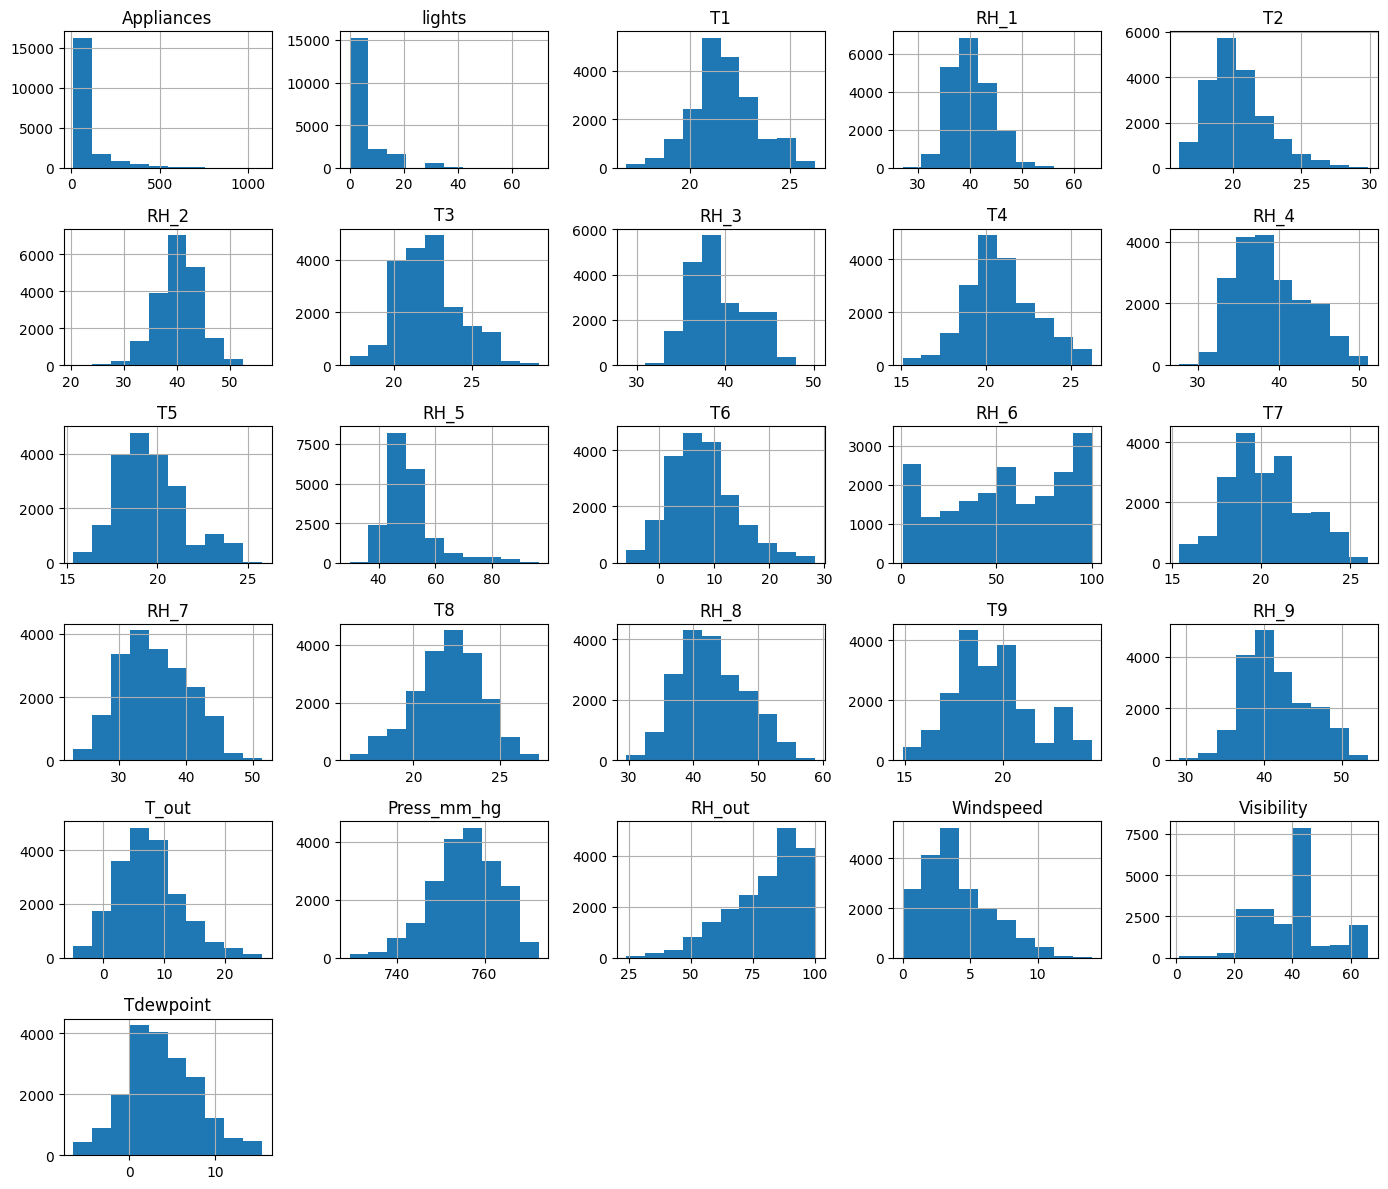

In [ ]:
# Histograms (EDA)

# distribution of all numerical features
df.hist(figsize=(14,12))
plt.tight_layout()
plt.show()

'''
Explanation:
This figure shows the distribution of all features. The target (Appliances) is right-skewed,
while most temperature and humidity variables are roughly normal.
'''


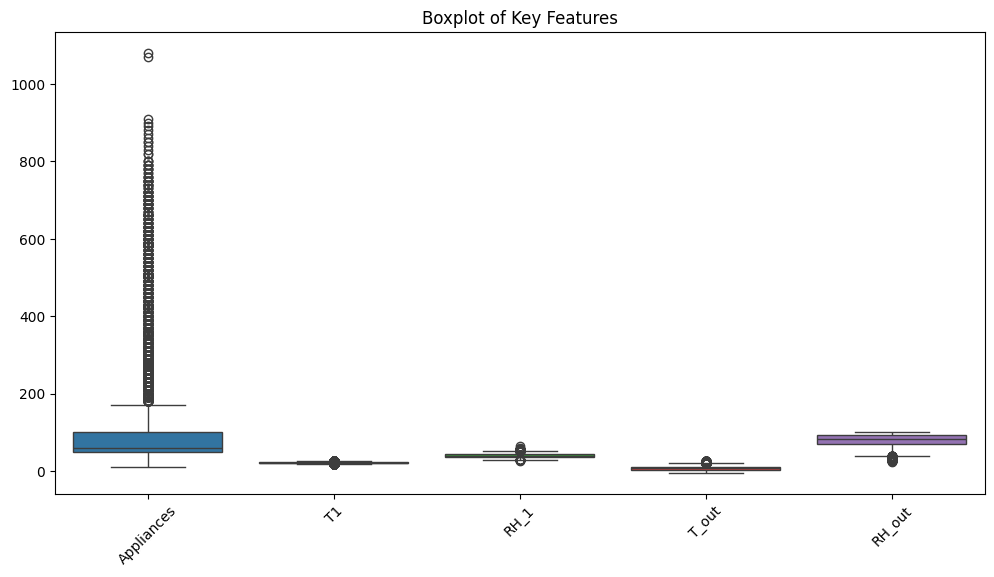

In [ ]:

# Boxplot (EDA)

# detect outliers (important features only)
plt.figure(figsize=(12,6))
sns.boxplot(data=df[['Appliances','T1','RH_1','T_out','RH_out']])
plt.xticks(rotation=45)
plt.title("Boxplot of Key Features")
plt.show()

'''
Explanation:
This boxplot shows the distribution and outliers of key features. Appliances has many extreme outliers,
indicating high variability, while other features are more stable.
This supports using robust models like Random Forest and XGBoost.
'''

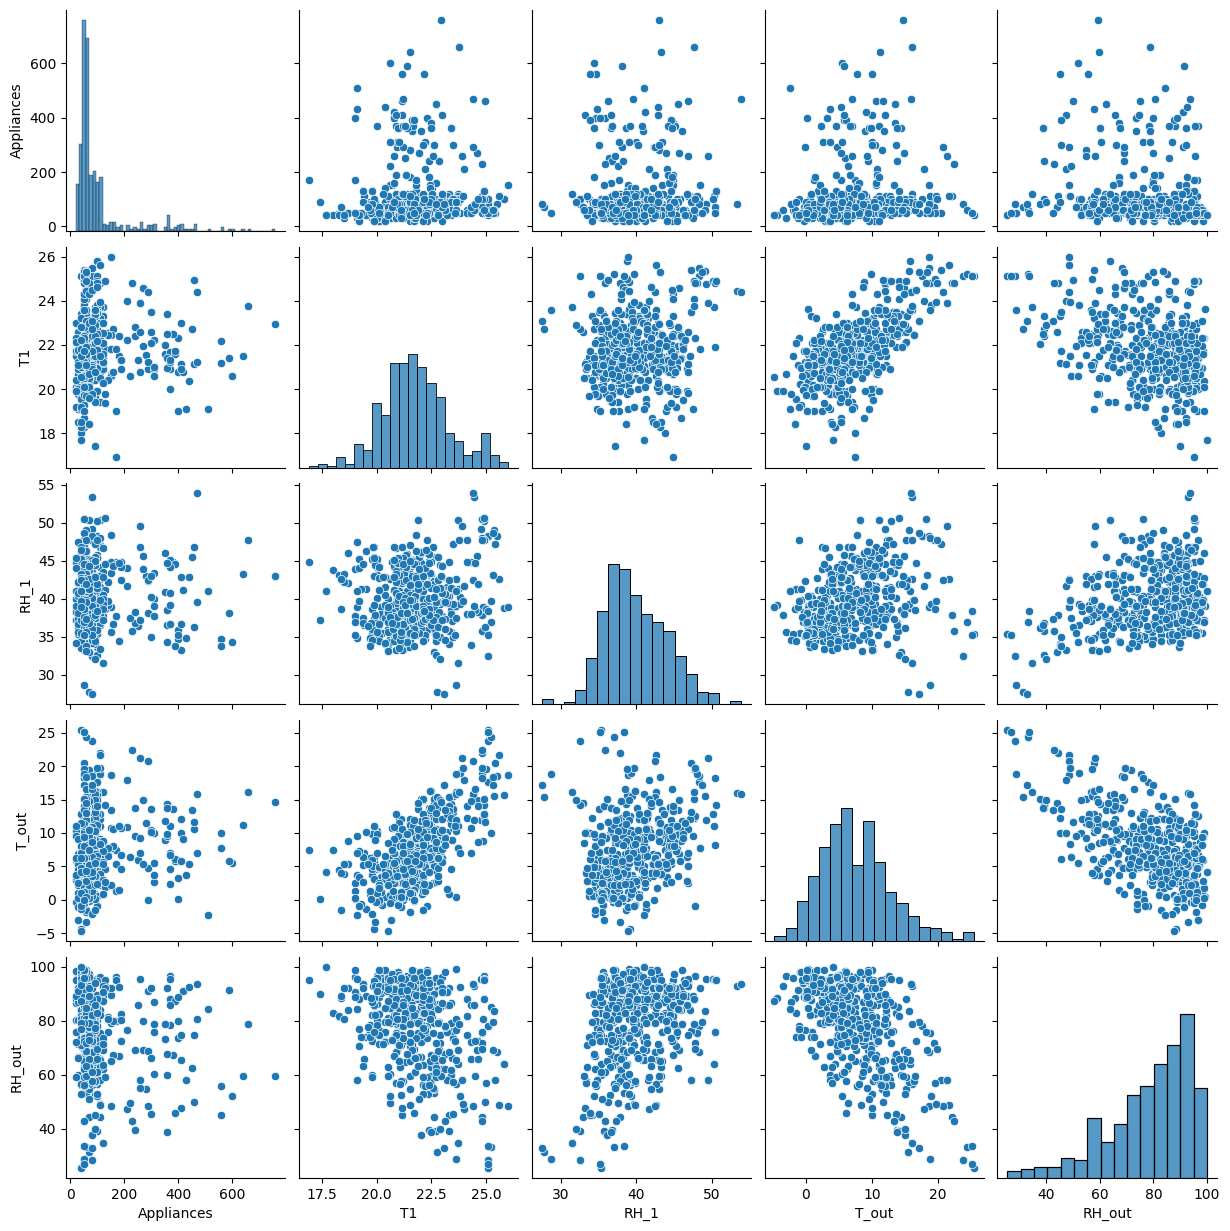

In [ ]:
# Pairplot (EDA)
# relationships

sns.pairplot(df[['Appliances','T1','RH_1','T_out','RH_out']].sample(500))
plt.show()


'''
Explanation:
This pairplot shows relationships between key features.
Most variables have weak-to-moderate relationships with Appliances,
indicating limited linear correlation. Some strong correlations exist between temperature features (e.g., T1 and T_out).
Overall, the scattered patterns suggest that nonlinear models are more suitable.
'''

**Correlation Analysis**

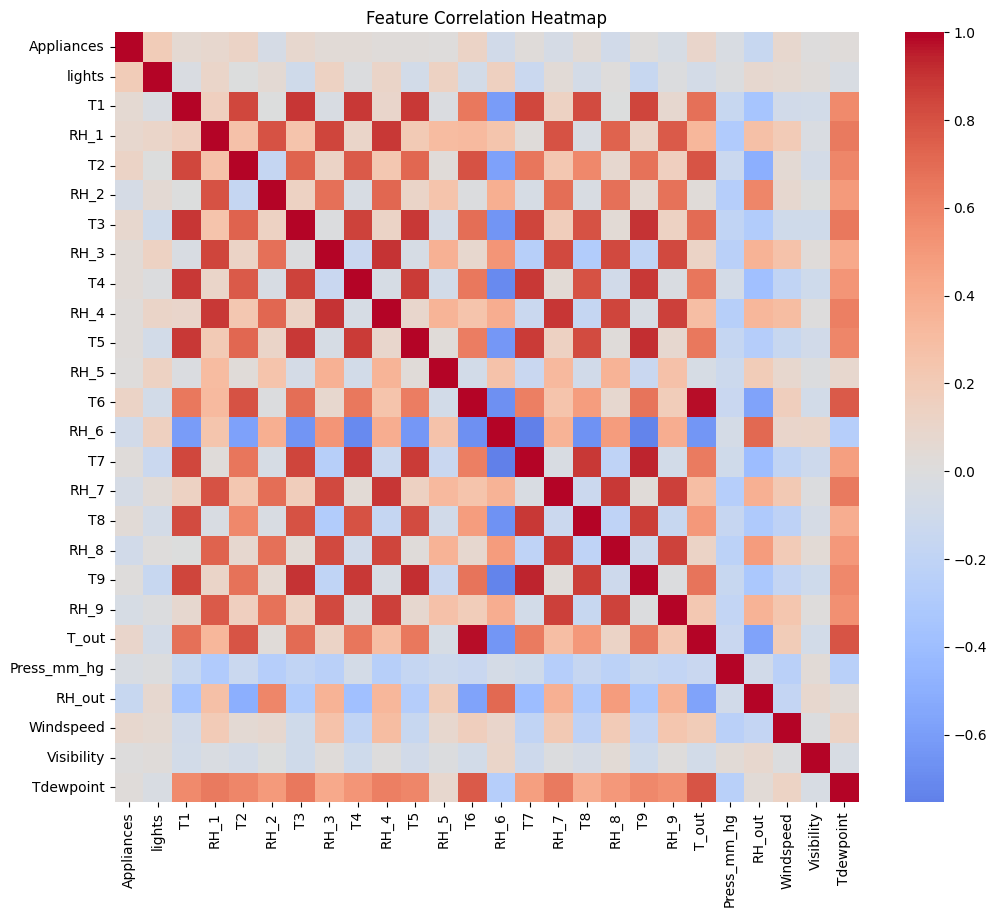

Appliances    1.000000
lights        0.197278
T2            0.120073
T6            0.117638
T_out         0.099155
Windspeed     0.087122
RH_1          0.086031
T3            0.085060
T1            0.055447
T4            0.040281
Name: Appliances, dtype: float64


In [ ]:
# Correlation Heatmap

# Drop non-numeric columns
df_numeric = df.drop(columns=['date'])

plt.figure(figsize=(12,10))
# Create correlation heatmap
# Blue = negative correlation, Red = positive correlation
sns.heatmap(df_numeric.corr(), cmap='coolwarm', center=0)
plt.title("Feature Correlation Heatmap")
plt.show()


# Correlation with Target
# Calculate correlation matrix
corr = df_numeric.corr()

# Get correlation values with target variable (Appliances)
corr_target = corr['Appliances'].sort_values(ascending=False)

print(corr_target.head(10))  # show top features

'''
Explanation:
The heatmap shows correlations between features. Most variables have weak correlation with Appliances (highest ≈ 0.19),
while strong correlations exist among temperature features. This suggests the need for nonlinear models.
'''

# 2. Data Preprocessing

Feature/target separation

In [ ]:
print("\n=== Feature / Target Separation ===")

# Convert date
df['date'] = pd.to_datetime(df['date'])

# SORT by date
df = df.sort_values(by='date')

# Feature engineering
df['hour'] = df['date'].dt.hour
df['weekday'] = df['date'].dt.weekday

# Drop original date
df = df.drop(columns=['date'])

# Now split features/target
target = "Appliances"

X = df.drop(columns=[target])
y = df[target]
print("Features shape:", X.shape)
print("Target shape:", y.shape)

'''
Explanation:
The dataset was sorted by time and new temporal features (hour and weekday) were created.
The original date column was removed, and the data was split into features (X) and target (y).
The dataset contains 19,735 samples with 27 input features.
'''


=== Feature / Target Separation ===
Features shape: (19735, 27)
Target shape: (19735,)


'\nExplanation:\nThe dataset was sorted by time and new temporal features (hour and weekday) were created. \nThe original date column was removed, and the data was split into features (X) and target (y). \nThe dataset contains 19,735 samples with 27 input features.\n'

Time-Based Train-Test Split

In [ ]:
print("\n=== Time-Based Train-Test Split ===")

split_index = int(0.8 * len(df))

X_train = X.iloc[:split_index]
X_test  = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test  = y.iloc[split_index:]

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

'''
Explanation:
A time-based approach is used to split the data (80% train, 20% test),
ensuring the model is trained on past data and tested on future data without leakage.
'''


=== Time-Based Train-Test Split ===
X_train: (15788, 27)
X_test: (3947, 27)
y_train: (15788,)
y_test: (3947,)


Feature Scaling

In [ ]:
print("\n=== Feature Scaling ===")

from sklearn.preprocessing import StandardScaler

# Convert ALL features to float
X_train = X_train.astype(float)
X_test = X_test.astype(float)

# Initialize scaler
scaler = StandardScaler()

# Apply scaling
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling completed!")
print("X_train_scaled shape:", X_train_scaled.shape)

# preview first rows
import pandas as pd
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns)
print("\nExample after scaling:")
print(X_train_scaled_df.head())


'''
Explanation:
Feature scaling transforms all variables into standardized values (z-scores),
where values are centered around 0 and scaled based on their variance.
This ensures all features are on a similar scale for model training.
'''


=== Feature Scaling ===
Scaling completed!
X_train_scaled shape: (15788, 27)

Example after scaling:
     lights        T1      RH_1        T2      RH_2        T3      RH_3  \
0  3.071295 -1.039517  2.103814 -0.284588  1.246472 -1.200652  1.681976   
1  3.071295 -1.039517  1.852407 -0.284588  1.226599 -1.200652  1.700697   
2  3.071295 -1.039517  1.742937 -0.284588  1.198385 -1.200652  1.745419   
3  4.267005 -1.039517  1.677998 -0.284588  1.187590 -1.200652  1.766219   
4  4.267005 -1.039517  1.752214 -0.284588  1.169926 -1.200652  1.766219   

         T4      RH_4        T5  ...        T9      RH_9     T_out  \
0 -0.761611  1.554962 -1.385479  ... -1.217218  1.014203  0.180377   
1 -0.761611  1.654543 -1.385479  ... -1.193835  1.021582  0.152122   
2 -0.810232  1.630574 -1.385479  ... -1.240601  1.006824  0.123867   
3 -0.834542  1.591599 -1.385479  ... -1.240601  0.982227  0.095612   
4 -0.834542  1.546388 -1.359694  ... -1.240601  0.982227  0.067357   

   Press_mm_hg    RH_out  

# 3. Linear Regression Model

---



In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import matplotlib.pyplot as plt
class LinearRegression:
    def __init__(self, fit_intercept=True):
        self.fit_intercept = fit_intercept
        self.coef_ = None

    def _add_intercept(self, X):
        ones = np.ones((X.shape[0], 1))
        return np.hstack((ones, X))

    def fit(self, X, y):
        X = np.asarray(X, dtype=float)
        y = np.asarray(y, dtype=float).reshape(-1, 1)

        if self.fit_intercept:
            X = self._add_intercept(X)

        # Normal equation
        self.coef_ = np.linalg.pinv(X.T @ X) @ X.T @ y
        return self

    def predict(self, X):
        X = np.asarray(X, dtype=float)

        if self.fit_intercept:
            X = self._add_intercept(X)

        return (X @ self.coef_).flatten()

def adjusted_r2(y_true, y_pred, n_features):
    n = len(y_true)
    r2 = r2_score(y_true, y_pred)

    if n <= n_features + 1:
        return np.nan

    return 1 - ((1 - r2) * (n - 1) / (n - n_features - 1))


def cross_validate_linear_regression(X, y, k=5):
    X = np.asarray(X, dtype=float)
    y = np.asarray(y, dtype=float)

    tscv = TimeSeriesSplit(n_splits=k)
    results = []

    for fold, (train_idx, test_idx) in enumerate(tscv.split(X), start=1):
        X_train_cv, X_test_cv = X[train_idx], X[test_idx]
        y_train_cv, y_test_cv = y[train_idx], y[test_idx]

        model = LinearRegression()
        model.fit(X_train_cv, y_train_cv)
        y_pred_cv = model.predict(X_test_cv)

        results.append({
            "Fold": fold,
            "R2": r2_score(y_test_cv, y_pred_cv),
            "RMSE": np.sqrt(mean_squared_error(y_test_cv, y_pred_cv)),
            "MAE": mean_absolute_error(y_test_cv, y_pred_cv)
        })

    results_df = pd.DataFrame(results)

    mean_row = results_df.mean(numeric_only=True)
    mean_row["Fold"] = "Average"

    results_df = pd.concat([results_df, pd.DataFrame([mean_row])], ignore_index=True)

    return results_df

In [ ]:
# Initialize and train the custom Linear Regression model
custom_lr_model = LinearRegression(fit_intercept=True)
custom_lr_model.fit(X_train, y_train)

# Make predictions on the scaled test set
y_pred_custom_lr = custom_lr_model.predict(X_test)

# Calculate evaluation metrics
rmse_custom_lr = np.sqrt(mean_squared_error(y_test, y_pred_custom_lr))
mae_custom_lr = mean_absolute_error(y_test, y_pred_custom_lr)
mape_custom_lr = np.mean(
    np.abs((y_test - y_pred_custom_lr) / np.where(y_test == 0, 1e-8, y_test))
) * 100
r2_custom_lr = r2_score(y_test, y_pred_custom_lr)

n = len(y_test)
p = X_train.shape[1]

if n - p - 1 > 0:
    adj_r2_custom_lr = 1 - (1 - r2_custom_lr) * (n - 1) / (n - p - 1)
else:
    adj_r2_custom_lr = np.nan

print("\n=== Linear Regression Performance ===")
print(f"RMSE   : {rmse_custom_lr:.4f}")
print(f"MAE    : {mae_custom_lr:.4f}")
print(f"MAPE   : {mape_custom_lr:.2f}%")
print(f"R²     : {r2_custom_lr:.4f}")
print(f"Adj R² : {adj_r2_custom_lr:.4f}")

'''
Explanation:
This cell trains the Linear Regression model and evaluates it using RMSE, MAE, MAPE, and The low R2 (≈ 0.17)
and high errors indicate that the model does not capture the complex patterns in the data well.
'''


=== Linear Regression Performance ===
RMSE   : 91.1331
MAE    : 52.5876
MAPE   : 62.91%
R²     : 0.1701
Adj R² : 0.1643


In [ ]:
# Perform cross-validation
cv_results_lr = cross_validate_linear_regression(X_train, y_train, k=5)

# Display results
print("Linear Regression Cross-Validation Performance")
display(cv_results_lr)

'''
Explanation:
This evaluates Linear Regression using TimeSeries cross-validation.
The results show unstable performance across folds and an average negative R2,
indicating the model fails to generalize well and is not suitable for this dataset.
'''

Linear Regression Cross-Validation Performance


/tmp/ipykernel_2331/2364320154.py:64: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Average' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  mean_row["Fold"] = "Average"


,Fold,R2,RMSE,MAE
0,1,-0.148361,119.070118,89.874094
1,2,0.065310,90.270056,55.962293
2,3,-0.159954,109.626316,72.721692
3,4,0.093320,99.277628,52.955865
4,5,0.091657,93.584971,59.332321
5,Average,-0.011605,102.365818,66.169253


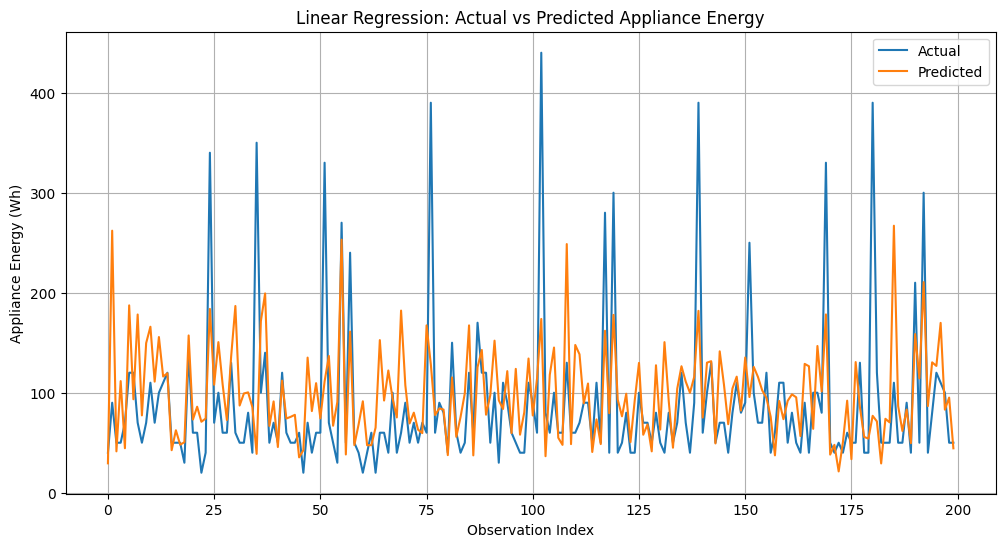

In [ ]:
plt.figure(figsize=(12, 6))

n = 200  # number of samples to display
plt.plot(range(n), y_test.iloc[:n].values, label='Actual')
plt.plot(range(n), y_pred_custom_lr[:n], label='Predicted')

plt.title('Linear Regression: Actual vs Predicted Appliance Energy')
plt.xlabel('Observation Index')
plt.ylabel('Appliance Energy (Wh)')
plt.legend()
plt.grid(True)
plt.show()

'''
Explanation:
This plot compares actual vs predicted values for Linear Regression.
The model captures the general trend but fails to follow sharp peaks,
leading to large errors, especially during high energy consumption periods.
'''

In [ ]:
# Extract coefficients
coefficients = custom_lr_model.coef_.flatten()

# Separate intercept and feature coefficients
intercept = coefficients[0]
feature_coeffs = coefficients[1:]

# Create a table
coef_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': feature_coeffs
})

# Sort by coefficient value or absolute impact
coef_df_sorted = coef_df.reindex(coef_df['Coefficient'].abs().sort_values(ascending=False).index)

print("Intercept:", intercept)
print(coef_df_sorted)

'''
Explanation:
This cell shows the learned coefficients of the Linear Regression model.
Features with larger absolute values have a stronger impact on predictions.
Positive values increase energy consumption, while negative values decrease it.
'''

Intercept: -43.13707995437399
        Feature  Coefficient
5            T3    26.588793
3            T2   -18.084574
2          RH_1    15.247094
4          RH_2   -13.445362
17           T9   -12.755149
19        T_out   -10.639120
11           T6     7.857771
15           T8     6.186839
6          RH_3     4.460928
24    Tdewpoint     3.837233
16         RH_8    -3.765043
13           T7     2.522833
7            T4    -2.430747
1            T1    -2.359528
26      weekday     2.049447
22    Windspeed     1.894173
0        lights     1.871288
14         RH_7    -1.685960
25         hour     1.060390
9            T5    -1.002835
21       RH_out    -0.902237
8          RH_4    -0.737904
12         RH_6     0.341985
18         RH_9    -0.335293
23   Visibility     0.186727
20  Press_mm_hg     0.169058
10         RH_5     0.116828


In [ ]:
print("Intercept:", round(intercept, 4))
display(coef_df_sorted.round(4))

Intercept: -43.1371


,Feature,Coefficient
5,T3,26.5888
3,T2,-18.0846
2,RH_1,15.2471
4,RH_2,-13.4454
17,T9,-12.7551
19,T_out,-10.6391
11,T6,7.8578
15,T8,6.1868
6,RH_3,4.4609
24,Tdewpoint,3.8372


# 4. Random Forest Model


=== Random Forest Model with Tuning ===
Fitting 5 folds for each of 54 candidates, totalling 270 fits

Best Parameters: {'max_depth': None, 'max_features': 'log2', 'min_samples_split': 2, 'n_estimators': 500}

=== Random Forest Performance ===
RMSE   : 62.3956
MAE    : 29.0550
MAPE   : 28.69%
R²     : 0.6110
Adj R² : 0.6083


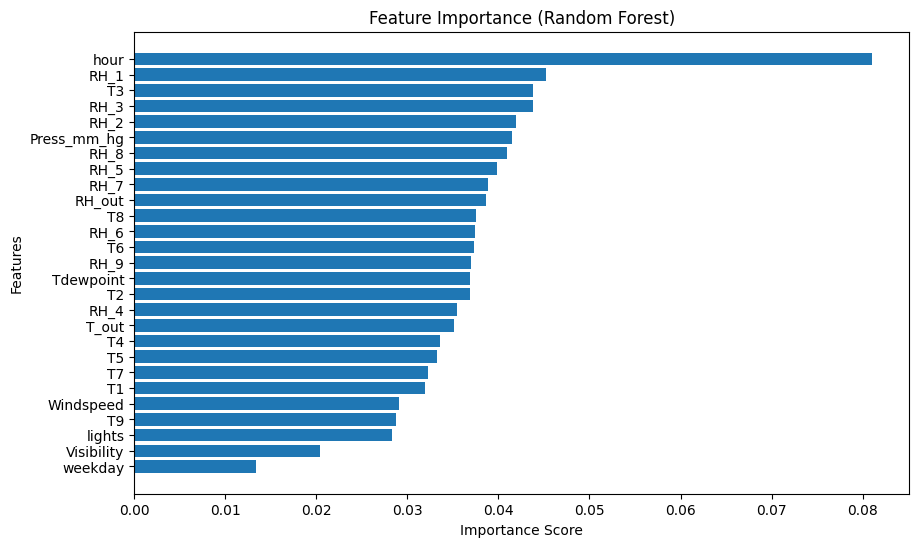

In [ ]:
print("\n=== Random Forest Model with Tuning ===")

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import matplotlib.pyplot as plt

# --------------------------------------------
# Step 1: Define model
# --------------------------------------------
rf = RandomForestRegressor(
    random_state=42,
    n_jobs=1
)

# --------------------------------------------
# Step 2: Parameter grid
# --------------------------------------------
param_grid = {
    "n_estimators": [100, 300, 500],
    "max_depth": [10, 20, None],
    "min_samples_split": [2, 5, 10],
    "max_features": ["sqrt", "log2"]
}


# --------------------------------------------
# Step 3: TimeSeries CV
# --------------------------------------------
tscv = TimeSeriesSplit(n_splits=5)

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=tscv,
    scoring="neg_mean_squared_error",
    verbose=1,
    n_jobs=-1
)

# --------------------------------------------
# Step 4: Train
# --------------------------------------------
grid_search.fit(X_train, y_train)

best_rf = grid_search.best_estimator_

print("\nBest Parameters:", grid_search.best_params_)

# --------------------------------------------
# Step 5: Predictions
# --------------------------------------------
y_pred_rf = best_rf.predict(X_test)

# --------------------------------------------
# Step 6: Metrics
# --------------------------------------------
print("\n=== Random Forest Performance ===")

rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf = mean_absolute_error(y_test, y_pred_rf)
mape_rf = np.mean(np.abs((y_test - y_pred_rf) / (y_test + 1))) * 100
r2_rf = r2_score(y_test, y_pred_rf)
n = len(y_test)
p = X_test.shape[1]
adj_r2_rf = 1 - (1 - r2_rf) * (n - 1) / (n - p - 1)

print(f"RMSE   : {rmse_rf:.4f}")
print(f"MAE    : {mae_rf:.4f}")
print(f"MAPE   : {mape_rf:.2f}%")
print(f"R²     : {r2_rf:.4f}")
print(f"Adj R² : {adj_r2_rf:.4f}")

# --------------------------------------------
# Step 7: Feature Importance
# --------------------------------------------
importances = best_rf.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(10,6))
plt.barh(range(len(indices)), importances[indices])
plt.yticks(range(len(indices)), np.array(X_train.columns)[indices])
plt.title("Feature Importance (Random Forest)")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.show()

'''
Explanation:
This cell trains a Random Forest model using hyperparameter tuning with TimeSeries cross-validation.
The results show strong performance (RMSE ≈ 62, R2 ≈ 0.61), significantly better than Linear Regression.
The feature importance plot indicates that temporal features (especially hour) and environmental variables have the highest impact on predictions.
'''

# 5. XGBoost Model


=== XGBoost Model with Tuning ===
Fitting 5 folds for each of 108 candidates, totalling 540 fits

Best Parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 9, 'n_estimators': 500, 'subsample': 0.8}

=== XGBoost Performance ===
RMSE   : 61.9704
MAE    : 29.2893
MAPE   : 29.25%
R²     : 0.6162
Adj R² : 0.6136


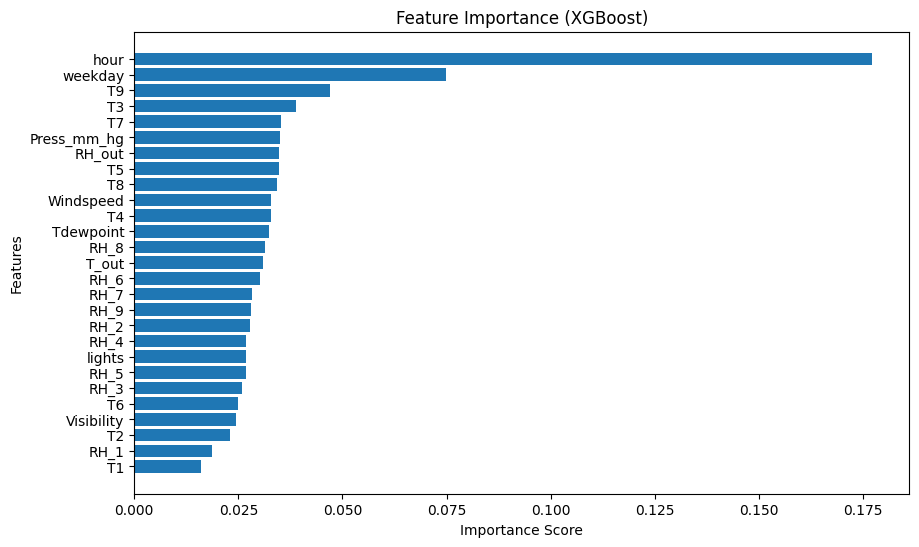

In [ ]:
print("\n=== XGBoost Model with Tuning ===")

from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import matplotlib.pyplot as plt

# --------------------------------------------
# Step 1: Define model
# --------------------------------------------
xgb = XGBRegressor(
    objective='reg:squarederror',
    eval_metric='rmse',
    random_state=42
)

# --------------------------------------------
# Step 2: Parameter grid
# --------------------------------------------
param_grid = {
    "n_estimators": [100, 300, 500],
    "max_depth": [3, 6, 9],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}

# --------------------------------------------
# Step 3: TimeSeries CV
# --------------------------------------------
tscv = TimeSeriesSplit(n_splits=5)

grid_search = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    cv=tscv,
    scoring="neg_mean_squared_error",
    verbose=1,
    n_jobs=-1
)

# Train
grid_search.fit(X_train, y_train)

best_xgb = grid_search.best_estimator_

print("\nBest Parameters:", grid_search.best_params_)

# --------------------------------------------
# Step 4: Predictions
# --------------------------------------------
y_pred_xgb = best_xgb.predict(X_test)

# --------------------------------------------
# Step 5: Metrics
# --------------------------------------------
print("\n=== XGBoost Performance ===")

rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
mape_xgb = np.mean(np.abs((y_test - y_pred_xgb) / (y_test + 1))) * 100
r2_xgb = r2_score(y_test, y_pred_xgb)
n = len(y_test)
p = X_test.shape[1]
adj_r2_xgb = 1 - (1 - r2_xgb) * (n - 1) / (n - p - 1)

print(f"RMSE   : {rmse_xgb:.4f}")
print(f"MAE    : {mae_xgb:.4f}")
print(f"MAPE   : {mape_xgb:.2f}%")
print(f"R²     : {r2_xgb:.4f}")
print(f"Adj R² : {adj_r2_xgb:.4f}")

# --------------------------------------------
# Step 6: Feature Importance
# --------------------------------------------
importances = best_xgb.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(10,6))
plt.barh(range(len(indices)), importances[indices])
plt.yticks(range(len(indices)), np.array(X_train.columns)[indices])
plt.title("Feature Importance (XGBoost)")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.show()

'''
Explanation:
This cell trains the XGBoost model using hyperparameter tuning with TimeSeries cross-validation.
It achieves the best performance (RMSE ≈ 61.97, R2 ≈ 0.62), outperforming all other models.
The feature importance plot shows that hour is the most influential feature, followed by temporal and environmental variables,
confirming strong time-based patterns in energy consumption.
'''

#6. ANN Model


=== ANN Model ===


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Training ANN...
Epoch 1/100
395/395 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.9763 - mae: 0.5850 - val_loss: 0.8235 - val_mae: 0.5165
Epoch 2/100
395/395 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.8802 - mae: 0.5411 - val_loss: 0.7938 - val_mae: 0.5133
Epoch 3/100
395/395 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.8503 - mae: 0.5220 - val_loss: 0.7644 - val_mae: 0.5041
Epoch 4/100
395/395 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.8258 - mae: 0.5133 - val_loss: 0.7513 - val_mae: 0.4836
Epoch 5/100
395/395 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.8035 - mae: 0.5019 - val_loss: 0.7381 - val_mae: 0.4909
Epoch 6/100
395/395 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.7907 - mae: 0.4947 - val_loss: 0.7354 - val_mae: 0.4528
Epoch 7/100
395/395 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.7692 - mae: 0.4874 - val_loss: 0.7268 - val_mae: 0.4456
Epoch 8/100
395/395 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.7630 - mae: 0.4814 - val_loss: 0.7084 - val_mae: 0.4453
Epoch 9/100
395/395 ━━━━━━━━━━━

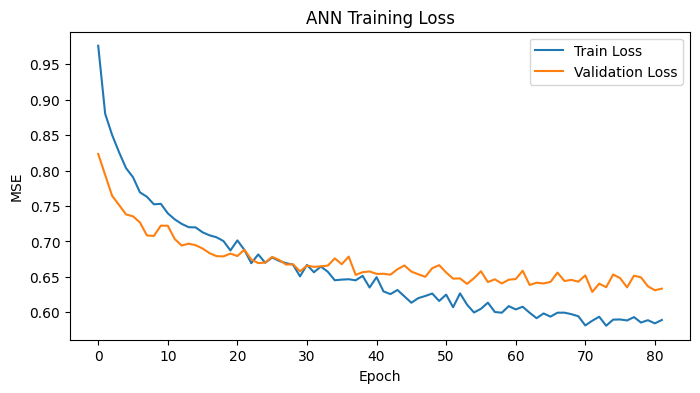

In [ ]:
print("\n=== ANN Model ===")

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import matplotlib.pyplot as plt

# --------------------------------------------
# 1. Use SCALED data
# --------------------------------------------
X_train_ready = X_train_scaled
X_test_ready = X_test_scaled

y_train_ready = y_train
y_test_ready = y_test

# --------------------------------------------
# 2. Normalize TARGET
# --------------------------------------------
from sklearn.preprocessing import StandardScaler

y_scaler = StandardScaler()

y_train_scaled = y_scaler.fit_transform(y_train_ready.values.reshape(-1, 1))

# --------------------------------------------
# 3. Build BETTER ANN
# --------------------------------------------
model = Sequential()

model.add(Dense(64, activation='relu', input_shape=(X_train_ready.shape[1],)))
model.add(Dropout(0.3))   # prevent overfitting

model.add(Dense(32, activation='relu'))
model.add(Dropout(0.2))

model.add(Dense(1))  # regression output

# --------------------------------------------
# 4. Compile model
# --------------------------------------------
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

# --------------------------------------------
# 5. Early stopping
# --------------------------------------------
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

# --------------------------------------------
# 6. Train model
# --------------------------------------------
print("\nTraining ANN...")

history = model.fit(
    X_train_ready,
    y_train_scaled,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

# --------------------------------------------
# 7. Predictions
# --------------------------------------------
y_pred_scaled = model.predict(X_test_ready)

# Convert back to original scale
y_pred_ann = y_scaler.inverse_transform(y_pred_scaled).flatten()

# --------------------------------------------
# 8. Metrics
# --------------------------------------------
rmse_ann = np.sqrt(mean_squared_error(y_test_ready, y_pred_ann))
mae_ann = mean_absolute_error(y_test_ready, y_pred_ann)
mape_ann = np.mean(np.abs((y_test_ready - y_pred_ann) / (y_test_ready + 1))) * 100
r2_ann = r2_score(y_test_ready, y_pred_ann)

n = len(y_test_ready)
p = X_test_ready.shape[1]

adj_r2_ann = 1 - (1 - r2_ann) * (n - 1) / (n - p - 1)

print("\n=== ANN Performance ===")
print(f"RMSE   : {rmse_ann:.4f}")
print(f"MAE    : {mae_ann:.4f}")
print(f"MAPE   : {mape_ann:.2f}%")
print(f"R²     : {r2_ann:.4f}")
print(f"Adj R² : {adj_r2_ann:.4f}")

# --------------------------------------------
# 9. Training plot
# --------------------------------------------
plt.figure(figsize=(8, 4))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('ANN Training Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.legend()
plt.show()


'''
Explanation:
This cell trains an ANN using scaled features and target normalization.
The model learns nonlinear patterns but achieves moderate performance (R2 ≈ 0.35),
lower than tree-based models. The training plot shows smooth convergence with slight overfitting, as validation loss stabilizes above training loss.
'''

# LSTM Model


=== Creating Sequences ===
X_seq shape: (19722, 10, 31)
y_seq shape: (19722,)

=== LSTM Model ===
Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


198/198 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 0.7293 - mae: 0.4638 - val_loss: 0.5961 - val_mae: 0.3975
Epoch 2/50
198/198 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - loss: 0.6146 - mae: 0.4161 - val_loss: 0.5763 - val_mae: 0.3708
Epoch 3/50
198/198 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.5543 - mae: 0.3915 - val_loss: 0.5404 - val_mae: 0.3494
Epoch 4/50
198/198 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.4982 - mae: 0.3682 - val_loss: 0.5133 - val_mae: 0.3528
Epoch 5/50
198/198 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.4480 - mae: 0.3490 - val_loss: 0.4873 - val_mae: 0.3317
Epoch 6/50
198/198 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.4263 - mae: 0.3365 - val_loss: 0.4898 - val_mae: 0.3289
Epoch 7/50
198/198 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.4170 - mae: 0.3298 - val_loss: 0.4854 - val_mae: 0.3057
Epoch 8/50
198/198 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.4062 - mae: 0.3231 - val_loss: 0.4971 - val_mae: 0.3334
Epoch 9/50
198/198 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss

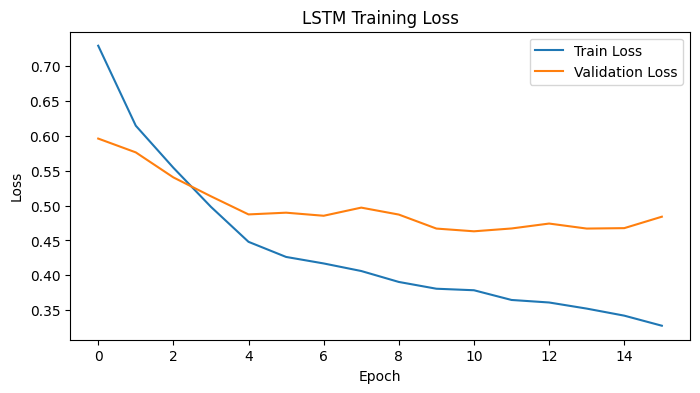

In [ ]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt


# Lag features
df['lag_1'] = df['Appliances'].shift(1)
df['lag_2'] = df['Appliances'].shift(2)
df['lag_3'] = df['Appliances'].shift(3)

# Rolling features
df['rolling_mean_3'] = df['Appliances'].rolling(3).mean()

# Drop NaN from lagging
df = df.dropna()


target = "Appliances"

X = df.drop(columns=[target])
y = df[target]

# Convert to float
X = X.astype(float)

scaler_X = StandardScaler()
X_scaled = scaler_X.fit_transform(X)

print("\n=== Creating Sequences ===")

import numpy as np

SEQ_LEN = 10

def create_sequences(X, y, seq_len):
    Xs, ys = [], []
    for i in range(seq_len, len(X)):
        Xs.append(X[i-seq_len:i])
        ys.append(y[i])
    return np.array(Xs), np.array(ys)

X_seq, y_seq = create_sequences(X_scaled, y.values, SEQ_LEN)

print("X_seq shape:", X_seq.shape)
print("y_seq shape:", y_seq.shape)


split_index = int(0.8 * len(X_seq))

X_train = X_seq[:split_index]
X_test = X_seq[split_index:]

y_train = y_seq[:split_index]
y_test = y_seq[split_index:]


y_scaler = StandardScaler()

y_train_scaled = y_scaler.fit_transform(y_train.reshape(-1,1))
y_test_scaled = y_scaler.transform(y_test.reshape(-1,1))


print("\n=== LSTM Model ===")

model = Sequential()

model.add(LSTM(64, input_shape=(X_train.shape[1], X_train.shape[2])))
model.add(Dropout(0.2))

model.add(Dense(32, activation='relu'))
model.add(Dense(1))

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train,
    y_train_scaled,
    validation_split=0.2,
    epochs=50,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

# Predict
y_pred_scaled = model.predict(X_test)
y_pred = y_scaler.inverse_transform(y_pred_scaled).flatten()

# Align lengths
min_len = min(len(y_test), len(y_pred))
y_test = y_test[:min_len]
y_pred = y_pred[:min_len]

# Evaluate
rmse_lstm = np.sqrt(mean_squared_error(y_test, y_pred))
mae_lstm = mean_absolute_error(y_test, y_pred)
mape_lstm = np.mean(np.abs((y_test - y_pred) / (y_test + 1))) * 100
r2_lstm = r2_score(y_test, y_pred)
n = len(y_test)
# number of features
p = X_test.shape[2]   # features dimension
adj_r2_lstm = 1 - (1 - r2_lstm) * (n - 1) / (n - p - 1)


print("\n=== FINAL LSTM RESULTS ===")
print(f"RMSE   : {rmse_lstm:.4f}")
print(f"MAE    : {mae_lstm:.4f}")
print(f"MAPE   : {mape_lstm:.2f}%")
print(f"R²     : {r2_lstm:.4f}")
print(f"Adj R² : {adj_r2_lstm:.4f}")

plt.figure(figsize=(8,4))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('LSTM Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

'''
Explanation:
This cell trains an LSTM model using sequential data with lag and rolling features to capture temporal dependencies.
Despite this, the model achieves moderate performance (R2 ≈ 0.33), lower than tree-based models.
The training plot shows convergence with slight overfitting, indicating limited ability to learn strong long-term patterns from the dataset.
'''


# Models Evaluation

In [ ]:
# Comparison Table
import pandas as pd

results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "ANN",
        "LSTM",
        "Random Forest",
        "XGBoost"
    ],
    "RMSE": [
        rmse_custom_lr,
        rmse_ann,
        rmse_lstm,
        rmse_rf,
        rmse_xgb
    ],
    "MAE": [
        mae_custom_lr,
        mae_ann,
        mae_lstm,
        mae_rf,
        mae_xgb
    ],
    "MAPE (%)": [
        mape_custom_lr,
        mape_ann,
        mape_lstm,
        mape_rf,
        mape_xgb
    ],
    "R2": [
        r2_custom_lr,
        r2_ann,
        r2_lstm,
        r2_rf,
        r2_xgb
    ],
    "Adj R2": [
        adj_r2_custom_lr,
        adj_r2_ann,
        adj_r2_lstm,
        adj_r2_rf,
        adj_r2_xgb
    ]
})

# Sort by best model
results = results.sort_values(by="R2", ascending=False)

results_formatted = results.copy()

# Apply rounding
results_formatted = results_formatted.round(2)

print("\n=== Comparison Table ===")
display(results_formatted)
results_formatted.to_csv("model_comparison.csv", index=False)

'''
Explanation:
This cell creates a comparison table of all models using key evaluation metrics.
The results are sorted by R2, showing that XGBoost performs best,
followed by Random Forest, while Linear Regression performs the worst.
'''



=== Comparison Table ===


,Model,RMSE,MAE,MAPE (%),R2,Adj R2
4,XGBoost,61.97,29.29,29.25,0.62,0.61
3,Random Forest,62.40,29.06,28.69,0.61,0.61
1,ANN,80.34,40.43,43.34,0.35,0.35
2,LSTM,74.21,43.57,47.85,0.33,0.32
0,Linear Regression,91.13,52.59,62.91,0.17,0.16


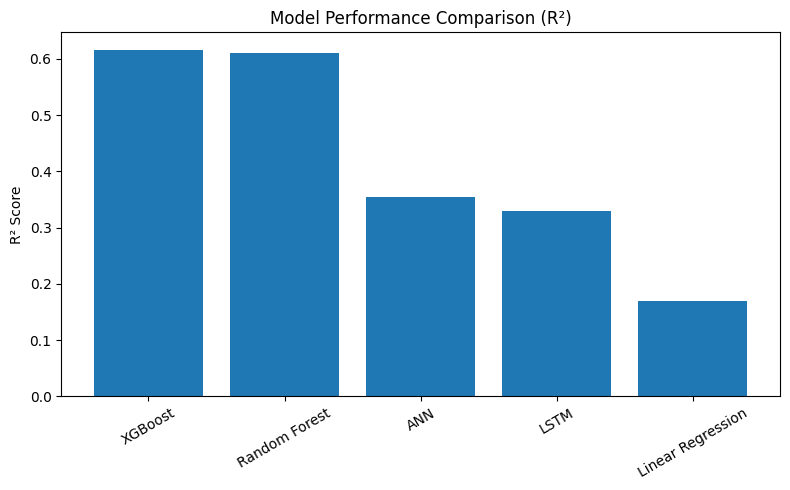

In [ ]:
# R² Model Performance Comparison
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.bar(results["Model"], results["R2"])
plt.ylabel("R² Score")
plt.title("Model Performance Comparison (R²)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

'''
Explanation:
This plot compares model performance using R2.
XGBoost and Random Forest achieve the highest scores, indicating better predictive accuracy,
while ANN and LSTM show moderate performance, and Linear Regression performs the worst.
'''

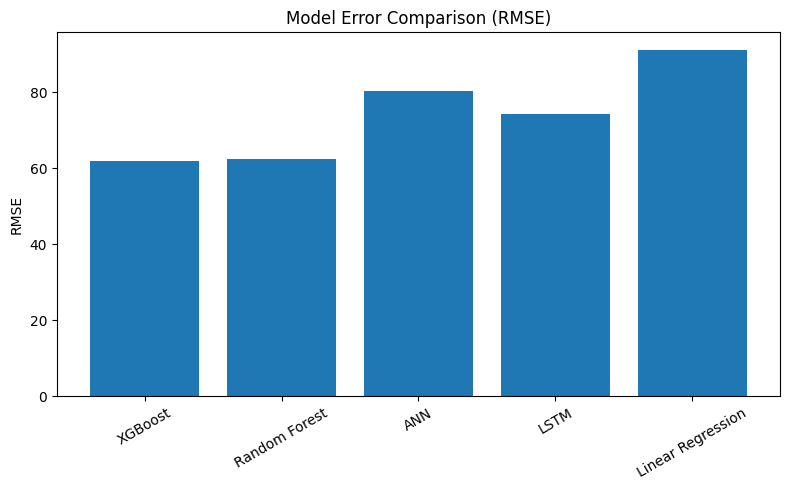

In [ ]:
# Model Error Comparison (RMSE)

plt.figure(figsize=(8,5))
plt.bar(results["Model"], results["RMSE"])
plt.ylabel("RMSE")
plt.title("Model Error Comparison (RMSE)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

'''
Explanation:
This plot compares model performance using RMSE.
XGBoost and Random Forest have the lowest errors, indicating better accuracy,
while ANN and LSTM show higher errors, and Linear Regression has the highest error.
'''

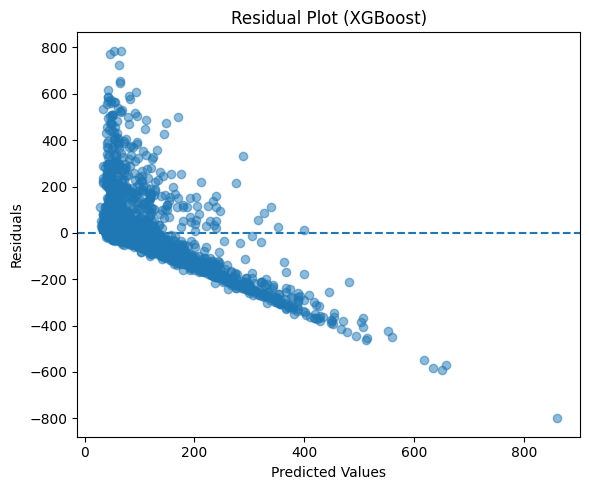

In [ ]:
# Residual Plot (XGBoost)

# Convert to numpy
y_true = np.array(y_test)
y_pred = np.array(y_pred_xgb)

# Align lengths
min_len = min(len(y_true), len(y_pred))

y_true = y_true[:min_len]
y_pred = y_pred[:min_len]

# Compute residuals
residuals = y_true - y_pred


plt.figure(figsize=(6,5))
plt.scatter(y_pred, residuals, alpha=0.5)

plt.axhline(0, linestyle='--')

plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot (XGBoost)")

plt.tight_layout()
plt.show()

'''
Explanation:
This residual plot shows the difference between actual and predicted values for XGBoost.
The pattern indicates the model tends to underestimate high energy values, and errors increase for larger predictions,
showing difficulty in capturing extreme peaks.
'''

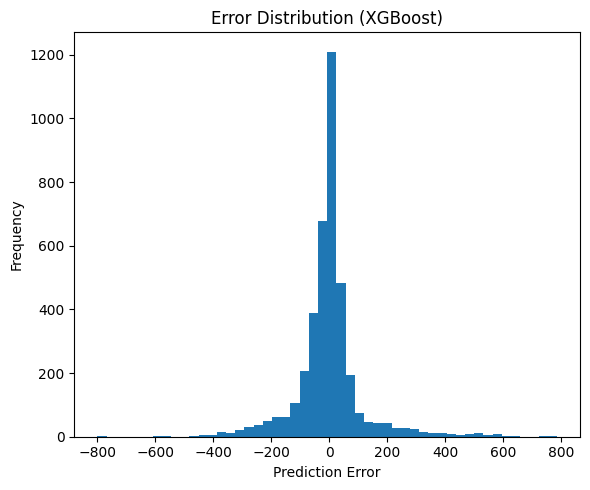

In [ ]:
# Error Distribution (XGBoost)

plt.figure(figsize=(6,5))
plt.hist(residuals, bins=50)

plt.xlabel("Prediction Error")
plt.ylabel("Frequency")
plt.title("Error Distribution (XGBoost)")

plt.tight_layout()
plt.show()

'''
Explanation:
This histogram shows the distribution of prediction errors for XGBoost.
Most errors are centered around zero, indicating the model is generally unbiased,
but the wide spread and long tails show larger errors for extreme values.
'''